# Aerial and latitude–height animations (Eriswil)

Notebook aligned with the publication pipeline: `scripts/processing_chain/run_publication_figures.py` reads
`config/publication_figures.yaml` (ensemble, paths, per-job CLI defaults). Process-budget and time-zero context live in
`config/psd_process_evolution.yaml`.

**Outputs:** frames under `output/gfx/png/aerials/<cs_run>/`, MP4/GIF under `output/gfx/mp4/` (same tree as other promoted figures; `run_publication_figures.py` syncs `output/gfx` → `output/gallery`).

**Data:** the notebook resolves `.../ensemble_output/<cs_run>` using the same fallbacks as `get_output_root` in `processing_paths.py`: `paths.server_root` in YAML, then `CS_RUNS_DIR`, `POLARCAP_OUTPUT_ROOT`, the Levante default tree, then local `scripts/data/registry/processed`. Jupyter kernels often lack shell exports—set `CS_RUNS_DIR` in IPython startup or assign `os.environ["CS_RUNS_DIR"] = "..."` before the config cell.



In [53]:
import glob
import json
import os
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as mpe
import matplotlib.dates as md
import numpy as np
import pandas as pd
import xarray as xr
import yaml
from matplotlib.colors import LogNorm
from dask.diagnostics import ProgressBar
from utilities.ensemble_config_diff import print_ensemble_config_diff



def find_repo_root(start: Path | None = None) -> Path:
    """Match notebooks/spectral_waterfall_minimal: stable root from any cwd."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "utilities" / "spectral_waterfall.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook inside the polarcap_analysis repository.")

def _job_tokens(pub: dict, job_key: str) -> list[str]:
    out: list[str] = []
    for x in (pub.get("default_args") or {}).get(job_key, []) or []:
        out.extend(str(x).split())
    return out


def _flag_value(tokens: list[str], name: str) -> str | None:
    try:
        i = tokens.index(name)
    except ValueError:
        return None
    return tokens[i + 1] if i + 1 < len(tokens) else None


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
for path in (REPO_ROOT, SRC_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from utilities.model_helpers import fetch_3d_data, convert_units_3d, harmonize_experiment_time_to_finest
from utilities.namelist_metadata import update_dataset_metadata
from utilities.plotting import add_ruler, create_fade_cmap, create_new_jet3, make_pastel
from utilities.processing_paths import find_ensemble_output_for_cs_run
import utilities.tools as tools

PUBLICATION_TICK_MAJOR_LEN = (7.0 + 3.5) / 2.0
PUBLICATION_TICK_MAJOR_W = (0.63 + 0.5) / 2.0
PUBLICATION_TICK_MINOR_LEN = (3.75 + 2.0) / 2.0
PUBLICATION_TICK_MINOR_W = (0.35 + 0.4) / 2.0

PUBLICATION_GRID_MAJOR_KW: dict[str, Any] = {
    "linestyle": "--",
    "linewidth": 0.25,
    "color": "black",
    "alpha": 0.6,
}
PUBLICATION_GRID_MINOR_KW: dict[str, Any] = {
    "linestyle": ":",
    "linewidth": 0.15,
    "color": "black",
    "alpha": 0.35,
}

PUBLICATION_RCPARAMS: dict[str, Any] = {
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "image.interpolation": "nearest",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 7,
    "figure.titlesize": 9,
    "figure.titleweight": "bold",
    "lines.linewidth": 0.8,
    "axes.linewidth": 0.5,
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": PUBLICATION_TICK_MAJOR_LEN,
    "ytick.major.size": PUBLICATION_TICK_MAJOR_LEN,
    "xtick.minor.size": PUBLICATION_TICK_MINOR_LEN,
    "ytick.minor.size": PUBLICATION_TICK_MINOR_LEN,
    "xtick.major.width": PUBLICATION_TICK_MAJOR_W,
    "ytick.major.width": PUBLICATION_TICK_MAJOR_W,
    "xtick.minor.width": PUBLICATION_TICK_MINOR_W,
    "ytick.minor.width": PUBLICATION_TICK_MINOR_W,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "patch.linewidth": 0.5,
    "axes.grid": False,
}

# Slightly more air between subplots and the figure edge (used by lat–lon, lat–height, MP4 frames).
PUBLICATION_CONSTRAINED_PAD: dict[str, float] = {
    "w_pad": 7.5 / 72.0,
    "h_pad": 7.5 / 72.0,
    "wspace": 0.075,
    "hspace": 0.075,
}


def apply_publication_style() -> None:
    plt.rcParams.update(PUBLICATION_RCPARAMS)


def apply_publication_axis_tick_geometry(ax) -> None:
    ax.minorticks_on()
    ax.tick_params(which="both", direction="out", top=True, right=True, bottom=True, left=True)
    ax.tick_params(
        which="major",
        direction="out",
        length=PUBLICATION_TICK_MAJOR_LEN,
        width=PUBLICATION_TICK_MAJOR_W,
    )
    ax.tick_params(
        which="minor",
        direction="out",
        length=PUBLICATION_TICK_MINOR_LEN,
        width=PUBLICATION_TICK_MINOR_W,
    )


def apply_publication_axis_grid(ax) -> None:
    ax.grid(True, which="major", **PUBLICATION_GRID_MAJOR_KW)
    ax.grid(True, which="minor", **PUBLICATION_GRID_MINOR_KW)
    ax.set_axisbelow(False)


def publication_icnc_cmap():
    return create_fade_cmap(
        make_pastel(create_new_jet3(), desaturation=0.35, darken=0.80),
        n_fade=2,
    )


def _contour_polyline_len(pts) -> float:
    pts = np.asarray(pts, dtype=float)
    if pts.ndim != 2 or len(pts) < 2:
        return 0.0
    d = np.sqrt(np.sum(np.diff(pts, axis=0) ** 2, axis=1))
    return float(d.sum())


def _point_on_polyline_at_fraction(pts, t: float) -> tuple[float, float]:
    pts = np.asarray(pts, dtype=float)
    t = max(0.0, min(1.0, float(t)))
    if len(pts) < 1:
        raise ValueError("empty contour")
    if len(pts) == 1:
        return float(pts[0, 0]), float(pts[0, 1])
    seg_len = np.sqrt(np.sum(np.diff(pts, axis=0) ** 2, axis=1))
    total = float(np.sum(seg_len))
    if total <= 1e-20:
        return float(pts[0, 0]), float(pts[0, 1])
    target = t * total
    acc = 0.0
    for i in range(len(pts) - 1):
        d = float(seg_len[i])
        if acc + d + 1e-15 >= target:
            u = 0.0 if d < 1e-20 else (target - acc) / d
            u = max(0.0, min(1.0, u))
            p0, p1 = pts[i], pts[i + 1]
            return float(p0[0] + u * (p1[0] - p0[0])), float(p0[1] + u * (p1[1] - p0[1]))
        acc += d
    return float(pts[-1, 0]), float(pts[-1, 1])


def stable_contour_level_label(
    ax,
    cs,
    level_index: int,
    level_value: float,
    *,
    fmt: str = "%.0f",
    fontsize: float = 6.0,
    color: str = "black",
    t_along: float = 0.5,
    zorder: float = 70.0,
    stroke_color: str | None = None,
) -> None:
    """One label on the longest sub-path, at a fixed parametric place (avoids clabel per-frame jumps)."""
    try:
        segs = cs.allsegs[level_index]
    except (IndexError, TypeError, AttributeError):
        return
    if not segs:
        return
    longest = max(segs, key=_contour_polyline_len)
    if _contour_polyline_len(longest) < 1e-12:
        return
    t_along = max(0.0, min(1.0, float(t_along)))
    x, y = _point_on_polyline_at_fraction(longest, t_along)
    if fmt.startswith("%"):
        label = fmt % (float(level_value),)
    else:
        label = str(level_value)
    pe = []
    if stroke_color is not None:
        pe.append(mpe.withStroke(linewidth=2.5, foreground=stroke_color, alpha=0.88))
    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, color=color, zorder=zorder, path_effects=pe, clip_on=True)


def _sym_log_norm_data_at_t(norm, t: float) -> float:
    """Data value v with norm(v) == t in [0,1] (sym-log inverse via bisection)."""
    t = max(0.0, min(1.0, float(t)))
    vmin, vmax = float(norm.vmin), float(norm.vmax)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        return vmin
    lo, hi = float(vmin), float(vmax)
    for _ in range(64):
        mid = 0.5 * (lo + hi)
        if float(norm(mid)) < t:
            lo = mid
        else:
            hi = mid
    return float(0.5 * (lo + hi))


def _plan_anom_cbar_tick_mpl(x: float) -> str:
    """Mathtext for exact signed powers of ten."""
    if not np.isfinite(x):
        return ""
    sgn, ax = ("-", abs(float(x))) if x < 0 else ("", float(x))
    if ax <= 1:
        return ""
    n = int(np.rint(np.log10(ax)))
    return f"${sgn}10^{{{n}}}$"


def _plan_anom_tick_min_abs(cfg: dict | None = None, fallback: float = 1.0) -> float:
    if cfg is not None:
        fallback = float(cfg.get("plan_anom_cbar_tick_min_abs", cfg.get("plan_anom_mid_white_abs", fallback)))
    return max(abs(float(fallback)), np.finfo(float).tiny)


def _plan_anom_cbar_decade_ticks(v_lo: float, v_hi: float, min_abs: float) -> list[float]:
    if not (np.isfinite(v_lo) and np.isfinite(v_hi)) or v_hi <= v_lo:
        return []
    max_abs = max(abs(v_lo), abs(v_hi))
    if max_abs <= 0:
        return []
    min_abs = min(max(abs(float(min_abs)), np.finfo(float).tiny), max_abs)
    e_min = int(np.ceil(np.log10(min_abs) - 1e-12))
    e_max = int(np.floor(np.log10(max_abs) + 1e-12))
    decades = [10.0**e for e in range(e_min, e_max + 1)]
    ticks = [-d for d in reversed(decades) if v_lo <= -d <= v_hi]
    ticks.extend(d for d in decades if v_lo <= d <= v_hi)
    return ticks


def _plan_anom_cbar_edges(
    v_lo: float,
    v_hi: float,
    min_abs: float,
    extra_edges: tuple[float, ...] = (),
) -> np.ndarray:
    ticks = _plan_anom_cbar_decade_ticks(v_lo, v_hi, min_abs)
    edges: list[float] = []
    for value in sorted((v_lo, *ticks, *extra_edges, v_hi)):
        if not v_lo <= value <= v_hi:
            continue
        if edges and np.isclose(value, edges[-1], rtol=1e-12, atol=0.0):
            continue
        edges.append(float(value))
    return np.asarray(edges, dtype=float)


def plan_anom_cmap_with_mid_white(
    base_name: str,
    norm,
    n_discrete: int,
    *,
    v_mid: float = 1e1,
    tick_min_abs: float | None = None,
    n_lut: int = 2048,
    under: str = "#000510",
    over: str = "#200000",
):
    """Flat RdBu bands whose color changes fall on exact signed-decade values."""
    base = plt.get_cmap(base_name)
    min_abs = _plan_anom_tick_min_abs(fallback=v_mid if tick_min_abs is None else tick_min_abs)
    edges = _plan_anom_cbar_edges(
        float(norm.vmin),
        float(norm.vmax),
        min_abs,
        extra_edges=(-abs(float(v_mid)), abs(float(v_mid))),
    )
    edge_t = np.asarray([float(norm(v)) for v in edges], dtype=float)
    edge_t[0], edge_t[-1] = 0.0, 1.0
    n_band = max(1, len(edges) - 1)
    color_t = np.linspace(0.0, 1.0, n_band) if n_band > 1 else np.array([0.5])
    colors = [mcolors.to_rgba(base(t), 1.0) for t in color_t]
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        if lo >= -abs(float(v_mid)) and hi <= abs(float(v_mid)):
            colors[i] = mcolors.to_rgba("white", 1.0)
    cdict: dict[str, list[tuple[float, float, float]]] = {"red": [], "green": [], "blue": [], "alpha": []}
    for channel, idx in (("red", 0), ("green", 1), ("blue", 2), ("alpha", 3)):
        for i, t in enumerate(edge_t):
            if i == 0:
                left = right = colors[0][idx]
            elif i == n_band:
                left = right = colors[-1][idx]
            else:
                left = colors[i - 1][idx]
                right = colors[i][idx]
            cdict[channel].append((float(t), float(left), float(right)))
    out = mcolors.LinearSegmentedColormap(f"{base_name}_plan_anom_decades", cdict, N=n_lut)
    out.set_under(under)
    out.set_over(over)
    return out


def plan_anom_cbar_discrete(cbar, norm, n_discrete: int, cfg: dict | None = None) -> None:
    """Place exact decade ticks on the color transitions."""
    if int(n_discrete) < 2:
        return
    min_abs = _plan_anom_tick_min_abs(cfg)
    tickv = _plan_anom_cbar_decade_ticks(float(norm.vmin), float(norm.vmax), min_abs)
    cbar.set_ticks(tickv)
    cbar.set_ticklabels([_plan_anom_cbar_tick_mpl(float(x)) for x in tickv])
    cbar.ax.minorticks_off()


ProgressBar().register()

In [19]:
# Fetch publication + PSD configs (same files as the publication runner / cloud overview script)
xr.set_options(keep_attrs=True)
apply_publication_style()

PUBLICATION_YAML = REPO_ROOT / "config" / "publication_figures.yaml"
PSD_YAML = REPO_ROOT / "config" / "psd_process_evolution.yaml"
FLARE_IDX_LIST = [0, 1, ]#2, 3, 4]
REF_IDX_LIST = [0, 1,] # 1, 1, 1]

TIME_DEBUG_STRIDE = 10  # > 1 for development speed
ALTITUDE_SLICE = (80, 90)

# Load publication + PSD configs (same files as the publication runner / cloud overview script)
with open(PUBLICATION_YAML) as f:
    pub = yaml.safe_load(f) or {}
with open(PSD_YAML) as f:
    psd = yaml.safe_load(f) or {}

ens = pub.get("ensemble") or {}
cs_run = str(ens.get("cs_run", "cs-eriswil__20260313_111441")) #cs-eriswil__20260318_153631
domain_xy = str(ens.get("domain", "50x42")) # "200x160"
flare_idx = int((psd.get("selection") or {}).get("experiment_index_default", 1))

# server_root = 
server_root = str(psd.get("paths", {}).get("server_root", ""))
ens_out, _tried = find_ensemble_output_for_cs_run(cs_run, config_runs_root=server_root)
if not ens_out:
    raise FileNotFoundError(
        "Could not find ensemble_output/"
        + cs_run
        + ". Tried:\n  "
        + "\n  ".join(_tried)
        + "\nSet paths.server_root in publication_figures.yaml, or export CS_RUNS_DIR "
        "(parent of RUN_ERISWILL_*x100), or POLARCAP_OUTPUT_ROOT (runs root or ensemble_output). "
        "Jupyter often does not inherit shell env: set variables in ~/.ipython/profile_default/startup "
        "or in this cell via os.environ before re-run."
    )
model_data_path = Path(ens_out) / cs_run

cf_tok = _job_tokens(pub, "cloud_field_overview")
runs_root = Path(server_root).expanduser() if server_root else Path(ens_out).parent
extpar_high = runs_root / "extPar_Eriswil_200x160.nc"
extpar_low = runs_root / "extPar_Eriswil_50x40.nc"
plot_start_s = _flag_value(cf_tok, "--plot-start")
plot_end_s = _flag_value(cf_tok, "--plot-end")
if domain_xy == "200x160":
    extpar_file = extpar_high
else:
    extpar_file = extpar_low

seed_start = np.datetime64((psd.get("time") or {}).get("seed_start", "2023-01-25T12:29:50"))

GFX_PNG = REPO_ROOT / "output" / "gfx" / "png" / "aerials" / cs_run.replace("/", "_")
GFX_MP4 = REPO_ROOT / "output" / "gfx" / "mp4"
GFX_PNG.mkdir(parents=True, exist_ok=True)
GFX_MP4.mkdir(parents=True, exist_ok=True)

print("cs_run:", cs_run, "domain:", domain_xy)
print("flare_idx:", flare_idx)
print("experiment:", model_data_path.name)

print("model_data_path:", model_data_path)
print("extpar_file:", extpar_file)
print("plot window (cloud_field_overview preset):", plot_start_s, "..", plot_end_s)


cs_run: cs-eriswil__20260313_111441 domain: 50x42
flare_idx: 0
experiment: cs-eriswil__20260313_111441
model_data_path: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100/ensemble_output/cs-eriswil__20260313_111441
extpar_file: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/extPar_Eriswil_50x40.nc
plot window (cloud_field_overview preset): 2023-01-25T12:29:50 .. 2023-01-25T13:05:00


## Load 3D flare member and reference members

In [20]:
flist_3d = sorted(glob.glob(str(model_data_path / "3D_??????????????.nc")))
if not flist_3d:
    raise FileNotFoundError(f"No 3D_*.nc under {model_data_path}")

json_files = sorted(model_data_path.glob("*.json"))
if not json_files:
    raise FileNotFoundError(f"No ensemble json next to 3D files in {model_data_path}")
with open(json_files[0]) as jsonfile:
    meta = json.load(jsonfile)

exp_names = [Path(f).name.split("_")[-1].split(".")[0] for f in flist_3d]
flare_candidates = [exp for exp in exp_names if meta[exp]["INPUT_ORG"]["sbm_par"]["lflare"]]
ref_candidates = [exp for exp in exp_names if not meta[exp]["INPUT_ORG"]["sbm_par"]["lflare"]]
if not flare_candidates:
    raise ValueError("No flare experiments (lflare) in ensemble meta.")
if not ref_candidates:
    raise ValueError("No reference experiments (lflare=False) in ensemble meta.")

# Load flare + reference runs once; keep expname as coordinate.
load_candidates = flare_candidates + [e for e in ref_candidates if e not in flare_candidates]
_ds_blocks = []
_dtimes = []
for exp_name in load_candidates:
    nc_file = next(f for f in flist_3d if exp_name in f)
    ds_i = fetch_3d_data(
        str(nc_file),
        str(extpar_file),
        meta[exp_name]["INPUT_ORG"],
        var_sets=["meteo", "bulk", "spec"],
        chunks={"time": 1},
    )
    ds_i = update_dataset_metadata(ds_i)
    print(f"altitude slicing between {ds_i.altitude[ALTITUDE_SLICE[0]].values:.2f} and {ds_i.altitude[ALTITUDE_SLICE[1]].values:.2f} m")
    ds_i = ds_i.isel(altitude=slice(*ALTITUDE_SLICE))
    ds_i = convert_units_3d(ds_i, ds_i["rho"])
    _dtimes.append(ds_i.time.values[1] - ds_i.time.values[0])
    _ds_blocks.append(ds_i)

_times = _ds_blocks[np.argmax(_dtimes)].time

print(
    "OUTPUT cadence (sbm_par.nc_output_hcomb last entry = dt, seconds):",
    {e: meta[e]["INPUT_ORG"]["sbm_par"].get("nc_output_hcomb") for e in load_candidates},
)
# Keep native cadence in ds_3d to avoid expensive interpolation on full 3D fields.
# We harmonize to 10 s later on reduced animation fields only.
ds_3d = xr.concat(_ds_blocks, dim=pd.Index(load_candidates, name="expname"))

# Development/debug speed-up: use every 4th model time step.
if TIME_DEBUG_STRIDE > 1:
    ds_3d = ds_3d.reindex(time=_times)
    ds_3d = ds_3d.isel(time=slice(None, None, TIME_DEBUG_STRIDE))

flare_exp_name = flare_candidates[flare_idx]
print("flare_candidates:", flare_candidates)
print("ref_candidates:", ref_candidates)
print("loaded expname:", list(ds_3d.expname.values))
print("time_debug_stride:", TIME_DEBUG_STRIDE, "n_time:", ds_3d.sizes.get("time"))
print("default flare_exp_name (paths, tracking):", flare_exp_name)
print_ensemble_config_diff(meta, load_candidates)

[########################################] | 100% Completed | 101.53 ms
[########################################] | 100% Completed | 201.20 ms
[########################################] | 100% Completed | 101.60 ms
[########################################] | 100% Completed | 201.48 ms
[########################################] | 100% Completed | 101.58 ms
[########################################] | 100% Completed | 201.28 ms
[########################################] | 100% Completed | 101.02 ms
[########################################] | 100% Completed | 101.47 ms
altitude slicing between 1507.03 and 1005.91 m
[########################################] | 100% Completed | 101.02 ms
[########################################] | 100% Completed | 101.11 ms
[########################################] | 100% Completed | 101.30 ms
[########################################] | 100% Completed | 201.20 ms
[########################################] | 100% Completed | 101.97 ms
[################

In [21]:
# Map-view layout: figure size from publication DPI (matches savefig in analysis scripts)
_dpi = float(plt.rcParams["savefig.dpi"])
pixel_w, pixel_h = 1920, 1080
resolution_label = "400m" if domain_xy == "50x40" else "100m"
resolution_deg = 0.004 if domain_xy == "50x40" else 0.001

cfg = {
    "resolution": resolution_label,
    "resolution_deg": resolution_deg,
    "dpi": int(_dpi),
    "pixel_size_latlon": (pixel_w, pixel_h//1.75),
    "pixel_size_latheight": (pixel_w, pixel_h//1.75),
    "poolsize": min(8, os.cpu_count() or 4),
    "lat_lon_frames_parallel": True,
    "plot_all_frames": True,
    # Lat–height panel: faint HSURF columns + thick mean, or one column synced to frame index. ("individual", "all_mean")
    "latheight_surf_mode": "all_mean", 
    "flare_lat": 47.07425,
    "flare_lon": 7.90522,
    "origin_lat": 47.070522,
    "origin_lon": 7.872991,
    "plot_xlim": (7.7671843, 7.94),
    "plot_ylim": (47.02, 47.12),
    "delta_x": float(1e3 * np.mean(np.diff(ds_3d.longitude.values)) * 111.13295254925466),
    "delta_y": float(1e3 * np.mean(np.diff(ds_3d.latitude.values)) * 111.13295254925466),
    "delta_t": float(np.mean(np.diff(ds_3d.time.astype("datetime64[s]")).astype(float))),
    "n_lon": ds_3d.longitude.size,
    "n_lat": ds_3d.latitude.size,
    "n_time": ds_3d.time.size,
    "vel_lims": [-0.5, 0.5],
    "v_lims_nf": [1e1, 1e5],
    "v_lims_nw": [1e3, 1e7],
    "plan_anom_percentile": 99.0,
    "plan_anom_cmap": "RdBu_r",
    "plan_anom_cmap_n_nf": 8,
    "plan_anom_cmap_n_nw": 8,
    "plan_anom_cmap_n_extra": 3,
    "plan_anom_mid_white_abs": 1e1,
    "plan_anom_cmap_extend_under": "#000510",
    "plan_anom_cmap_extend_over": "#200000",
    "v_lims_anom_nf": [-1e5, 1e5],
    "v_lims_anom_nw": [-1e5, 1e5],
    "anom_symlog_linthresh": None,
    "anom_symlog_linthresh_nf": 10,
    "anom_symlog_linthresh_nw": 10,
    "nf_anom_contour_nw": 10,
    "tick_size": int(plt.rcParams["xtick.labelsize"]),
    "axis_size": int(plt.rcParams["axes.labelsize"]),
    "timer_size": int(plt.rcParams["figure.titlesize"]) + 2,
}

data_extpar = xr.open_mfdataset(str(extpar_file), chunks="auto")
# for top view
lat2d = data_extpar["lat"].values[7:-7, 7:-7]
lon2d = data_extpar["lon"].values[7:-7, 7:-7]
height = data_extpar["HSURF"].values[7:-7, 7:-7]

# for lat-height view
lat1d = data_extpar["lat"].mean("rlon").values[7:-7]
surf_height = data_extpar["HSURF"].values[7:-7, 7:-7]
surf_height_mean = data_extpar["HSURF"].mean("rlon").values[7:-7]



[########################################] | 100% Completed | 101.65 ms
[########################################] | 100% Completed | 201.48 ms
[########################################] | 100% Completed | 101.41 ms
[########################################] | 100% Completed | 201.25 ms
[########################################] | 100% Completed | 100.89 ms
[########################################] | 100% Completed | 201.28 ms
[########################################] | 100% Completed | 101.73 ms
[########################################] | 100% Completed | 201.34 ms
[########################################] | 100% Completed | 101.00 ms
[########################################] | 100% Completed | 201.06 ms
[########################################] | 100% Completed | 101.17 ms
[########################################] | 100% Completed | 101.05 ms


In [22]:
# Flare–reference pairs from FLARE_IDX_LIST / REF_IDX_LIST (indices into flare_candidates / ref_candidates).
eps_f32 = np.finfo(np.float32).eps

def _ishape_of(exp_name): return meta[exp_name]["INPUT_ORG"]["sbm_par"].get("ishape")
def _flare_emission_inp_of(exp_name): return meta[exp_name]["INPUT_ORG"]["flare_sbm"].get("flare_emission")
def _flare_emission_ccn_of(exp_name): return meta[exp_name]["INPUT_ORG"]["flare_sbm"].get("flare_dn")

_fi = list(FLARE_IDX_LIST)
_ri = list(REF_IDX_LIST)
if len(_fi) != len(_ri): raise ValueError(f"FLARE_IDX_LIST length {len(_fi)} != REF_IDX_LIST length {len(_ri)}")

pair_rows = []
for j, (i_f, i_r) in enumerate(zip(_fi, _ri)):
    if not (0 <= i_f < len(flare_candidates)): raise IndexError(f"FLARE_IDX_LIST[{j}]={i_f} invalid for len(flare_candidates)={len(flare_candidates)}")
    if not (0 <= i_r < len(ref_candidates)):   raise IndexError(f"REF_IDX_LIST[{j}]={i_r} invalid for len(ref_candidates)={len(ref_candidates)}")
    fexp, rexp = flare_candidates[i_f], ref_candidates[i_r]
    pair_rows.append((  fexp, 
                        rexp, 
                        _ishape_of(fexp),
                         _flare_emission_inp_of(fexp), 
                        _flare_emission_ccn_of(fexp)) )

n_pair = len(pair_rows)
if n_pair < 1: raise ValueError("No pairs built from FLARE_IDX_LIST / REF_IDX_LIST.")

for i in range(n_pair):
    print(f"pair {i} (flare_i, ref_i):", list(zip(_fi, _ri))[i])
    print(f"pair {i} (flare, ref, ishape, flare_emission_inp, flare_emission_ccn):", pair_rows[i])

_col = ds_3d[["nw", "nf", "dz"]].sel(
    latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
    longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
)
_col = _col.isel(diameter=slice(30, None)).sum("diameter")
_col = (_col[["nw", "nf"]] * _col["dz"]).sum("altitude")
_col = xr.where(_col < eps_f32, np.nan, _col)

itime_cmp = int(_col.sizes["time"] // 2) # select middle time step for comparison
_tlab = str(np.asarray(_col.time.isel(time=itime_cmp).values).squeeze())
_d0 = _col["nf"].isel(time=itime_cmp).sel(expname=pair_rows[0][0])

if "longitude2D" in _d0.coords:
    lon_q = _d0.longitude2D.values
    lat_q = _d0.latitude2D.values
else:
    lon_q, lat_q = np.meshgrid(_d0.longitude.values, _d0.latitude.values)


pair 0 (flare_i, ref_i): (0, 0)
pair 0 (flare, ref, ishape, flare_emission_inp, flare_emission_ccn): ('20260313111445', '20260313111441', 2, 1000000.0, 0.0)
pair 1 (flare_i, ref_i): (1, 1)
pair 1 (flare, ref, ishape, flare_emission_inp, flare_emission_ccn): ('20260313111448', '20260313111446', 4, 1000000.0, 0.0)


In [23]:
# # 1) Originals: n_flare_runs x 4 -> [flare_nw, flare_nf, ref_nw, ref_nf]
# fig_org, axs_org = plt.subplots(n_pair, 4, figsize=(16.0, 3.6 * n_pair), sharex=True, sharey=True, constrained_layout=True)
# if n_pair == 1:
#     axs_org = np.array([axs_org])
        
# orig_vmin = {"nw": 1e4, "nf": 1e1}
# orig_vmax = {"nw": 3e5, "nf": 1e5}

# for i, (fexp, rexp, ish, _, _) in enumerate(pair_rows):
#     panel_data = [
#         ("flare nw", _col["nw"].isel(time=itime_cmp).sel(expname=fexp), orig_vmin["nw"], orig_vmax["nw"]),
#         ("flare nf", _col["nf"].isel(time=itime_cmp).sel(expname=fexp), orig_vmin["nf"], orig_vmax["nf"]),
#         ("ref nw",   _col["nw"].isel(time=itime_cmp).sel(expname=rexp), orig_vmin["nw"], orig_vmax["nw"]),
#         ("ref nf",   _col["nf"].isel(time=itime_cmp).sel(expname=rexp), orig_vmin["nf"], orig_vmax["nf"]),
#     ]
#     for j, (lbl, da_, vmin_, vmax_) in enumerate(panel_data):
#         pm = axs_org[i, j].pcolormesh( lon_q, lat_q, da_.values, shading="nearest", cmap=publication_icnc_cmap(), norm=LogNorm(vmin=vmin_, vmax=vmax_) )
#         axs_org[i, j].set_title(f"{lbl} | ishape={ish} | {fexp if 'flare' in lbl else rexp} | {_flare_emission_inp_of(fexp)} | {_flare_emission_ccn_of(fexp)}", fontsize=plt.rcParams["axes.titlesize"])
#         fig_org.colorbar(pm, ax=axs_org[i, j], shrink=0.72, pad=0.01)
    
#     axs_org[i, 0].set_ylabel("latitude")

# for j in range(4):
#     axs_org[-1, j].set_xlabel("longitude")
# fig_org.suptitle(f"Original maps (column-integrated) at t = {_tlab}", fontsize=plt.rcParams["figure.titlesize"], fontweight=plt.rcParams.get("figure.titleweight", "bold"))
# for ax in np.ravel(axs_org):
#     apply_publication_axis_tick_geometry(ax)
#     apply_publication_axis_grid(ax)
# fig_org.savefig(GFX_PNG / f"original_maps_{cfg['resolution']}_{cs_run.replace('__', '_')}.png")


In [24]:
# if False:
#     # 2) Anomaly: n_flare_runs x 2 -> [nw_anom, nf_anom] where anomaly = flare - ref.
#     anom_list = []
#     for fexp, rexp, ish, _, _ in pair_rows:
#         anom_list.append((
#             fexp, rexp, ish, {  "nw": _col["nw"].isel(time=itime_cmp).sel(expname=fexp) - _col["nw"].isel(time=itime_cmp).sel(expname=rexp),
#                                 "nf": _col["nf"].isel(time=itime_cmp).sel(expname=fexp) - _col["nf"].isel(time=itime_cmp).sel(expname=rexp)  },
#         ))

#     fig_anom, axs_anom = plt.subplots(n_pair, 2, figsize=(10.0, 3.6 * n_pair), sharex=True, sharey=True, constrained_layout=True)
#     if n_pair == 1:
#         axs_anom = np.array([axs_anom])
#     anom_vmax = {}
#     for v in ["nw", "nf"]:
#         vals = np.array([a[3][v].values for a in anom_list])
#         anom_vmax[v] = max(float(np.nanpercentile(np.abs(vals), 99.0)), 1e-12)

#     for i, (fexp, rexp, ish, anom) in enumerate(anom_list):
#         for j, v in enumerate(["nw", "nf"]):
#             vm = anom_vmax[v]
#             pm = axs_anom[i, j].pcolormesh( lon_q, lat_q, anom[v].values, shading="nearest", cmap="RdBu_r", vmin=-vm, vmax=vm )
#             axs_anom[i, j].set_title(f"Δ{v}: ishape={ish} | {fexp} - {rexp} | {_flare_emission_inp_of(fexp):.0e} | {_flare_emission_ccn_of(fexp)}", fontsize=plt.rcParams["axes.titlesize"])
#             fig_anom.colorbar(pm, ax=axs_anom[i, j], shrink=0.72, pad=0.01)
        
#         axs_anom[i, 0].set_ylabel("latitude")
        
#     for j in range(2):
#         axs_anom[-1, j].set_xlabel("longitude")
        
#     fig_anom.suptitle(rf"Anomaly maps (flare - ref) at d$_{{xy}}$ = {cfg['resolution']}", fontsize=plt.rcParams["figure.titlesize"], fontweight=plt.rcParams.get("figure.titleweight", "bold"))
#     for ax in np.ravel(axs_anom):
#         apply_publication_axis_tick_geometry(ax)
#         apply_publication_axis_grid(ax)
#     fig_anom.savefig(GFX_PNG / f"anomaly_maps_{cfg['resolution']}_{cs_run.replace('__', '_')}.png")

#     stop


In [25]:
# # 3) Difference of anomalies (nw, nf): using first two anomaly pairs.
# if n_pair >= 2:
#     diff_anom = { "nw": anom_list[1][3]["nw"] - anom_list[0][3]["nw"],
#                   "nf": anom_list[1][3]["nf"] - anom_list[0][3]["nf"] }
#     fig_da, axs_da = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True, constrained_layout=True)
#     for j, v in enumerate(["nw", "nf"]):
#         vm = max(float(np.nanpercentile(np.abs(diff_anom[v].values), 99.0)), 1e-12)
#         pm = axs_da[j].pcolormesh( lon_q, lat_q, diff_anom[v].values, shading="nearest", cmap="RdBu_r", vmin=-vm, vmax=vm)
#         axs_da[j].set_title(f"Δ(Δ{v})", fontsize=10)
#         axs_da[j].set_xlabel("longitude")
#         fig_da.colorbar(pm, ax=axs_da[j], shrink=0.80, pad=0.02)
        
#     axs_da[0].set_ylabel("latitude")
#     p0 = f"({anom_list[0][0]} - {anom_list[0][1]})"
#     p1 = f"({anom_list[1][0]} - {anom_list[1][1]})"
#     fig_da.suptitle(f"Difference of anomalies: {p1} - {p0} at t = {_tlab}", fontsize=11)
#     fig_da.savefig(GFX_PNG / f"difference_of_anomalies_{cfg['resolution']}_{cs_run.replace('__', '_')}.png")
# else:
#     print("Need >=2 pairs for difference-of-anomalies figure.")

## Plotting helpers (top view)

In [35]:
def add_map_annotations(ax, cfg):
    ax.scatter(cfg["origin_lon"], cfg["origin_lat"], s=70, marker="x", color="red", zorder=2)
    ax.scatter(cfg["flare_lon"],  cfg["flare_lat"],  s=50, marker="o", facecolor="none", edgecolor="white", lw=2.5,zorder=2)
    ax.scatter(cfg["flare_lon"],  cfg["flare_lat"],  s=50, marker="o", facecolor="none", edgecolor="red", lw=1.0, zorder=2 )
    add_ruler(ax, 47.05, 7.804, cfg["flare_lat"], cfg["flare_lon"])
    seeding = {
        "royalblue": ([7.90476, 7.90568], [47.07602, 47.07248]),
        "orange": ([7.89828, 7.89919], [47.07526, 47.07172]),
        "green": ([7.91125, 7.91216], [47.07676, 47.07322]),
    }
    for _c, (lon, lat) in seeding.items():
        dx, dy = np.diff(lon)[0], np.diff(lat)[0]
        ext_lon, ext_lat = [lon[0] - dx, lon[1] + dx], [lat[0] - dy, lat[1] + dy]
        ax.plot(lon, lat, color="black", lw=0.9)
        ax.plot(ext_lon, ext_lat, color="black", alpha=0.4, lw=0.6)


## Top-view animation

In [36]:
apply_publication_style()
png_path = str(GFX_PNG)
os.makedirs(png_path, exist_ok=True)

# Plan view: per pair load full nf/nw/dz, harmonize time, anomaly on native fields, then
# diameter slice and column integration. dz is from the flare run only (not differenced).

def _load_exp_cube(exp: str) -> xr.Dataset:
    return ds_3d.sel(expname=exp)[["nf", "nw", "dz"]].persist()

blocks, labels = [], []
for fexp, rexp, *_ in pair_rows:
    blocks.append(_load_exp_cube(fexp))
    labels.append(f"{fexp}__flare")
    blocks.append(_load_exp_cube(rexp))
    labels.append(f"{rexp}__ref")

h_cubes = harmonize_experiment_time_to_finest(blocks, exp_names=labels)

plan_nf_by_exp, plan_nw_by_exp = {}, {}
for j, (fexp, rexp, *_) in enumerate(pair_rows):
    fl = h_cubes[2 * j]
    rf = h_cubes[2 * j + 1]
    d = fl.copy()
    d["nf"] = fl["nf"] - rf["nf"]
    d["nw"] = fl["nw"] - rf["nw"]
    d = d.isel(diameter=slice(30, None)).sum("diameter")
    mod_e = d[["nf", "nw"]] * d["dz"]
    integ = mod_e.sum("altitude")
    plan_nf_by_exp[fexp] = integ["nf"]
    plan_nw_by_exp[fexp] = integ["nw"]

print(
    "Plan-view: column-integrated ICNC/CDNC anomalies (flare - ref) from Δ(nf, nw) on 4D, "
    "then slice/integrate."
)


[########################################] | 100% Completed | 1.61 sms
[########################################] | 100% Completed | 1.71 s
[########################################] | 100% Completed | 1.81 s
[########################################] | 100% Completed | 1.51 sms
[########################################] | 100% Completed | 1.61 s
[########################################] | 100% Completed | 1.61 s
[########################################] | 100% Completed | 2.22 sms
[########################################] | 100% Completed | 2.22 s
[########################################] | 100% Completed | 2.32 s
[########################################] | 100% Completed | 1.62 sms
[########################################] | 100% Completed | 1.72 s
[########################################] | 100% Completed | 1.72 s
Plan-view: column-integrated ICNC/CDNC anomalies (flare - ref) from Δ(nf, nw) on 4D, then slice/integrate.


[########################################] | 100% Completed | 884.78 ms
[########################################] | 100% Completed | 977.82 ms
[########################################] | 100% Completed | 1.08 s
[########################################] | 100% Completed | 1.08 s
[########################################] | 100% Completed | 1.18 s
[########################################] | 100% Completed | 1.28 s
[########################################] | 100% Completed | 101.35 ms
[########################################] | 100% Completed | 114.59 ms
[########################################] | 100% Completed | 201.39 ms
[########################################] | 100% Completed | 201.53 ms
[########################################] | 100% Completed | 201.59 ms
[########################################] | 100% Completed | 201.91 ms
[########################################] | 100% Completed | 100.89 ms
[########################################] | 100% Completed | 201.06 ms
[###

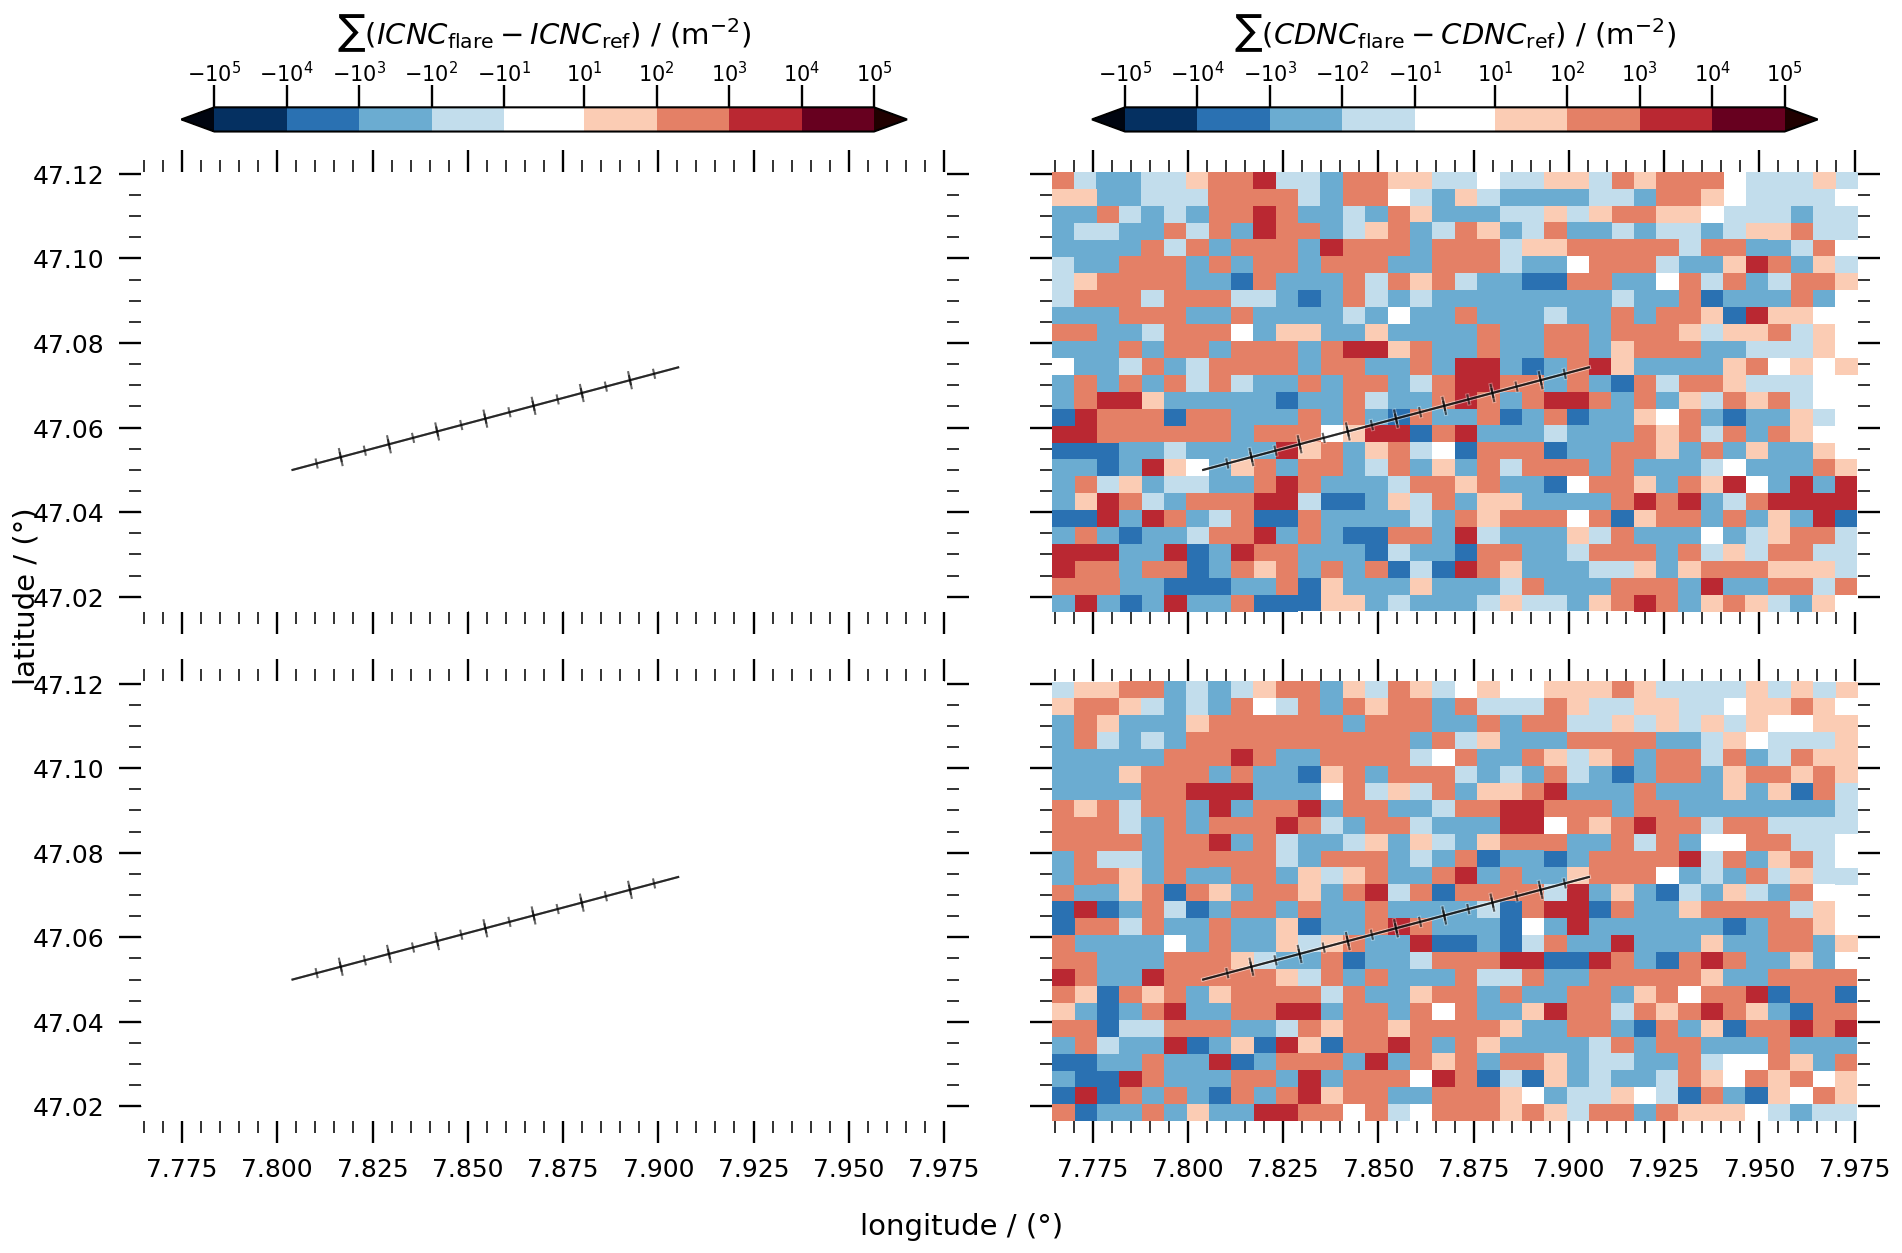

In [54]:
from matplotlib.colors import SymLogNorm
import matplotlib.pyplot as plt

n_flare = len(flare_candidates)
time_vals = plan_nf_by_exp[flare_candidates[0]].time.values
_n_time = len(time_vals)
_lat_lon_nf_arr = {e: np.asarray(plan_nf_by_exp[e].values) for e in flare_candidates}
_lat_lon_nw_arr = {e: np.asarray(plan_nw_by_exp[e].values) for e in flare_candidates}
_lon2D_arr = {e: np.asarray(plan_nf_by_exp[e].longitude2D) for e in flare_candidates}
_lat2D_arr = {e: np.asarray(plan_nf_by_exp[e].latitude2D) for e in flare_candidates}

_ap = float(cfg.get("plan_anom_percentile", 99.0))
_af = np.concatenate([_lat_lon_nf_arr[e].ravel() for e in flare_candidates])
_aw = np.concatenate([_lat_lon_nw_arr[e].ravel() for e in flare_candidates])
if cfg.get("v_lims_anom_nf") is not None:
    vmin_nf, vmax_nf = map(float, cfg["v_lims_anom_nf"])
else:
    _a = max(float(np.nanpercentile(np.abs(_af[np.isfinite(_af)]), _ap)), 1e-20)
    vmin_nf, vmax_nf = -_a, _a
if cfg.get("v_lims_anom_nw") is not None:
    vmin_nw, vmax_nw = map(float, cfg["v_lims_anom_nw"])
else:
    _a = max(float(np.nanpercentile(np.abs(_aw[np.isfinite(_aw)]), _ap)), 1e-20)
    vmin_nw, vmax_nw = -_a, _a


def _anom_symlog_linthresh(vmin: float, vmax: float, which: str) -> float:
    t = cfg.get(f"anom_symlog_linthresh_{which}")
    if t is not None:
        return float(t)
    t = cfg.get("anom_symlog_linthresh")
    if t is not None:
        return float(t)
    s = min(abs(vmin), abs(vmax))
    if not np.isfinite(s) or s <= 0:
        s = max(1e-20, 0.5 * float(abs(vmax - vmin)))
    return max(1e-20, 0.01 * s)


_ltnf = _anom_symlog_linthresh(vmin_nf, vmax_nf, "nf")
_ltnw = _anom_symlog_linthresh(vmin_nw, vmax_nw, "nw")
norm_anom_nf = SymLogNorm(linthresh=_ltnf, linscale=0.5, vmin=vmin_nf, vmax=vmax_nf, base=10)
norm_anom_nw = SymLogNorm(linthresh=_ltnw, linscale=0.5, vmin=vmin_nw, vmax=vmax_nw, base=10)

_cmap_anom = str(cfg.get("plan_anom_cmap", "RdBu_r"))
_n_ex = int(cfg.get("plan_anom_cmap_n_extra", 3))
_n_c_nf = int(cfg.get("plan_anom_cmap_n_nf", 8)) + _n_ex
_n_c_nw = int(cfg.get("plan_anom_cmap_n_nw", 8)) + _n_ex
_v_mid_w = float(cfg.get("plan_anom_mid_white_abs", 10))
_und = str(cfg.get("plan_anom_cmap_extend_under", "#0b2d5c"))
_ovr = str(cfg.get("plan_anom_cmap_extend_over", "#7a0a0a"))
cmap_anom_nf = plan_anom_cmap_with_mid_white(
    _cmap_anom, norm_anom_nf, _n_c_nf, v_mid=_v_mid_w, under=_und, over=_ovr,
)
cmap_anom_nw = plan_anom_cmap_with_mid_white(
    _cmap_anom, norm_anom_nw, _n_c_nw, v_mid=_v_mid_w, under=_und, over=_ovr,
)

fig_w = (cfg["pixel_size_latlon"][0] / cfg["dpi"])
fig_h = cfg["pixel_size_latlon"][1] / cfg["dpi"] * max(1, n_flare)
fig_ll, axes = plt.subplots(n_flare, 2, figsize=(fig_w, fig_h), sharex=True, sharey=True, constrained_layout=True)
fig_ll.set_constrained_layout_pads(**PUBLICATION_CONSTRAINED_PAD)
if n_flare == 1:
    axs = np.array([axes])
_cb_ax0, _cb_ax1 = np.atleast_2d(axes)[0, 0], np.atleast_2d(axes)[0, 1]

pm_nf_all, pm_nw_all = [], []
for axs, exp in zip(axes, flare_candidates):
    for ax in axs:
        add_map_annotations(ax, cfg)
        ax.pcolormesh(lon2d, lat2d, height, cmap="terrain", vmin=300, alpha=0.55, zorder=1)
        apply_publication_axis_tick_geometry(ax)
        apply_publication_axis_grid(ax)
        ax.tick_params(axis="both", which="major", labelsize=cfg["tick_size"])

    pm_nf = axs[0].pcolormesh(
        _lon2D_arr[exp],
        _lat2D_arr[exp],
        _lat_lon_nf_arr[exp][0],
        cmap=cmap_anom_nf,
        norm=norm_anom_nf,
        zorder=50,
    )
    pm_nf_all.append(pm_nf)
    pm_nw = axs[1].pcolormesh(
        _lon2D_arr[exp],
        _lat2D_arr[exp],
        _lat_lon_nw_arr[exp][0],
        cmap=cmap_anom_nw,
        norm=norm_anom_nw,
        zorder=50,
    )
    pm_nw_all.append(pm_nw)
    _c_lvl = cfg.get("nf_anom_contour_nw", 0.0)
    if _c_lvl is not None:
        _znf0 = _lat_lon_nf_arr[exp][0]
        _znf0 = np.where(np.isfinite(_znf0), _znf0, np.nan)
        _cs_nw0 = axs[1].contour(
            _lon2D_arr[exp], _lat2D_arr[exp], _znf0, levels=[float(_c_lvl)], colors="white", linestyles="--",
            linewidths=1.1, zorder=60, antialiased=True,
        )
        _cl_fs = int(cfg.get("contour_clabel_size", max(4, int(cfg.get("tick_size", 6)) - 1)))
        _t_leg = float(cfg.get("contour_clabel_t_along", 0.5))
        stable_contour_level_label(
            axs[1], _cs_nw0, 0, float(_c_lvl), fmt="%.0f", fontsize=_cl_fs, color="w",
            t_along=_t_leg, stroke_color="0.1",
        )
    for ax in axs:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)

fig_ll.text(0.5, 0.0, "longitude / (°)", ha="center", va="top", fontsize=cfg["axis_size"])
fig_ll.text(0.02, 0.5, "latitude / (°)", ha="right", va="center", fontsize=cfg["axis_size"], rotation=90)
cb_nf = fig_ll.colorbar(pm_nf_all[0], ax=_cb_ax0, extend="both", shrink=0.9, aspect=30, pad=0.075, orientation="horizontal", location="top", drawedges=False)
cb_nw = fig_ll.colorbar(pm_nw_all[0], ax=_cb_ax1, extend="both", shrink=0.9, aspect=30, pad=0.075, orientation="horizontal", location="top", drawedges=False)
plan_anom_cbar_discrete(cb_nf, norm_anom_nf, _n_c_nf, cfg)
plan_anom_cbar_discrete(cb_nw, norm_anom_nw, _n_c_nw, cfg)
cb_nf.set_label(r"$\sum ( ICNC_{\mathrm{flare}} - ICNC_{\mathrm{ref}})$ / (m$^{-2}$)", fontsize=cfg["axis_size"])
cb_nw.set_label(r"$\sum ( CDNC_{\mathrm{flare}} - CDNC_{\mathrm{ref}})$ / (m$^{-2}$)", fontsize=cfg["axis_size"])
cb_nf.ax.tick_params(labelsize=cfg["tick_size"]-1, pad=0.05)
cb_nw.ax.tick_params(labelsize=cfg["tick_size"]-1, pad=0.05)


# fig_ll.suptitle("Top-view column ICNC & CDNC anomalies (flare$-$ref)", ...)



In [38]:
import concurrent.futures

def _write_lat_lon_frame(iframe: int) -> int:
    import matplotlib
    matplotlib.use("Agg", force=True)
    import matplotlib.pyplot as plt
    n_f = len(flare_candidates)
    fig_w_ = (cfg["pixel_size_latlon"][0] / cfg["dpi"])
    fig_h_ = cfg["pixel_size_latlon"][1] / cfg["dpi"] * max(1, n_f)
    fig_wk, axes_wk = plt.subplots(
        n_f, 2, figsize=(fig_w_, fig_h_), sharex=True, sharey=True, constrained_layout=True,
    )
    fig_wk.set_constrained_layout_pads(**PUBLICATION_CONSTRAINED_PAD)
    if n_f == 1:
        _ = np.array([axes_wk])
    _c0, _c1 = np.atleast_2d(axes_wk)[0, 0], np.atleast_2d(axes_wk)[0, 1]
    _cl_fs = int(cfg.get("contour_clabel_size", max(4, int(cfg.get("tick_size", 6)) - 1)))
    pm_nf_w, pm_nw_w = [], []
    for axs, exp in zip(axes_wk, flare_candidates):
        for ax in axs:
            add_map_annotations(ax, cfg)
            ax.pcolormesh(lon2d, lat2d, height, cmap="terrain", vmin=300, alpha=0.55, zorder=1)
            apply_publication_axis_tick_geometry(ax)
            apply_publication_axis_grid(ax)
            ax.tick_params(axis="both", which="major", labelsize=cfg["tick_size"])
        pm_nf = axs[0].pcolormesh(
            _lon2D_arr[exp],
            _lat2D_arr[exp],
            _lat_lon_nf_arr[exp][iframe],
            cmap=cmap_anom_nf,
            norm=norm_anom_nf,
            zorder=50,
        )
        pm_nf_w.append(pm_nf)
        pm_nw = axs[1].pcolormesh(
            _lon2D_arr[exp],
            _lat2D_arr[exp],
            _lat_lon_nw_arr[exp][iframe],
            cmap=cmap_anom_nw,
            norm=norm_anom_nw,
            # vmin=-1e3,
            # vmax=1e3,
            zorder=50,
        )
        pm_nw_w.append(pm_nw)
        _c_lvl = cfg.get("nf_anom_contour_nw", 0.0)
        _c_lvl_2 = cfg.get("nf_anom_contour_nw_2", 100)
        _c_lvl_3 = cfg.get("nf_anom_contour_nw_3", 10000)
        if _c_lvl is not None:
            for _c_lvl, _clr_out, _clr_in in zip((_c_lvl_2, _c_lvl_3), ("white", "white"), ("black", "red")):
                _znf = _lat_lon_nf_arr[exp][iframe]
                _znf = np.where(np.isfinite(_znf), _znf, np.nan)

                _cs1 = axs[1].contour(
                    _lon2D_arr[exp], _lat2D_arr[exp], _znf, levels=[float(_c_lvl_2)], colors=_clr_out, linestyles="--",
                    linewidths=2.1, zorder=60, antialiased=True,
                )
                axs[1].contour(
                    _lon2D_arr[exp], _lat2D_arr[exp], _znf, levels=[float(_c_lvl_2)], colors=_clr_in, linestyles="--",
                    linewidths=0.9, zorder=61, antialiased=True,

                )
            
                _t_leg = float(cfg.get("contour_clabel_t_along", 0.5))
                for _cs, _lv, _dta in (
                    # (_cs0, float(_c_lvl), 0.0),
                    (_cs1, float(_c_lvl_2), float(cfg.get("contour_clabel_t_along2_offset", 0.0))),
                ):
                    stable_contour_level_label(
                        axs[1], _cs, 0, _lv, fmt="%.0f", fontsize=_cl_fs, color="0.1",
                        t_along=_t_leg + _dta, stroke_color="white",
                    )
        for ax in axs:
            # ax.set_title(f"{lbl} | {exp}", fontsize=plt.rcParams["axes.titlesize"], weight="semibold")
            for side in ("top", "right", "bottom", "left"):
                ax.spines[side].set_visible(False)
                
    fig_wk.text(0.5, 0.01, "longitude / (°)", ha="center", va="top", fontsize=cfg["axis_size"])
    fig_wk.text(0.01, 0.5, "latitude / (°)", ha="right", va="center", fontsize=cfg["axis_size"], rotation=90)
    cb1 = fig_wk.colorbar(
        pm_nf_w[0], ax=_c0, extend="both", shrink=0.9, aspect=25, pad=0.05, orientation="horizontal", location="top",
        drawedges=False,
    )
    cb_nf.set_label(r"$\sum ( ICNC_{\mathrm{flare}} - ICNC_{\mathrm{ref}})$ / (m$^{-2}$)", fontsize=cfg["axis_size"])
    cb1.ax.tick_params(labelsize=cfg["tick_size"])
    cb2 = fig_wk.colorbar(
        pm_nw_w[0], ax=_c1, extend="both", shrink=0.9, aspect=25, pad=0.05, orientation="horizontal", location="top",
        drawedges=False,
    )
    cb_nw.set_label(r"$\sum ( CDNC_{\mathrm{flare}} - CDNC_{\mathrm{ref}})$ / (m$^{-2}$)", fontsize=cfg["axis_size"])
    cb2.ax.tick_params(labelsize=cfg["tick_size"])
    
    plan_anom_cbar_discrete(cb1, norm_anom_nf, _n_c_nf, cfg)
    plan_anom_cbar_discrete(cb2, norm_anom_nw, _n_c_nw, cfg)
    
    ts = np.datetime_as_string(time_vals[iframe], unit="s").replace("T", "  ")
    fig_wk.text(0.95, 0.825, f"{ts[-8:]} UTC", ha="right", va="top", fontweight="semibold", fontsize=cfg["timer_size"])
    out = GFX_PNG / f"lat_lon_frame_{iframe:03d}_{cfg['resolution']}_area.png"
    fig_wk.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    plt.close(fig_wk)
    return iframe


if True:
    for pattern in ("lat_lon_frame_*.png",):
        for f in glob.glob(os.path.join(png_path, pattern)):
            os.remove(f)
    print("Cleaned:", png_path)

    if cfg["plot_all_frames"]:
        n_workers = min(int(cfg.get("poolsize", 8)), int(_n_time), int(os.cpu_count() or 8))
        use_pool = bool(cfg.get("lat_lon_frames_parallel", True)) and sys.platform == "linux" and n_workers > 1 and int(_n_time) > 1
        if use_pool:
            chunksize = max(1, int(_n_time) // max(1, 8 * n_workers))
            with concurrent.futures.ProcessPoolExecutor(max_workers=n_workers) as ex:
                list(ex.map(_write_lat_lon_frame, range(int(_n_time)), chunksize=chunksize))
        else:
            for iframe in range(int(_n_time)):
                _write_lat_lon_frame(iframe)
        print("All multi-column plan-view frames saved")

    input_pattern = os.path.join(png_path, f"lat_lon_frame_%03d_{cfg['resolution']}_area.png")
    out_mp4 = GFX_MP4 / f"lat_lon_multi_flare_{cfg['resolution']}_{cs_run.replace('__', '_')}.mp4"
    tools.convert_to_video(str(input_pattern), str(out_mp4), resolution="1920:1080", loop_count=2, framerate=15)
    print(out_mp4.resolve().as_uri())


Cleaned: /home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260313_111441


All multi-column plan-view frames saved
FFMPEG created MP4 file: /home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/mp4/lat_lon_multi_flare_100m_cs-eriswil_20260313_111441.mp4
file:///home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/mp4/lat_lon_multi_flare_100m_cs-eriswil_20260313_111441.mp4


## Latitude–height section + domain ice mass

Uses the same `cfg`, `ds_3d`, and `GFX_*` roots. Time-series colours use the Okabe–Ito process palette (see `PROC_COLORS` in the repo).

In [30]:
# # Lat–height: time-harmonize flare/ref on native nf/nw, flare − ref, then long-sum and diameter-slice; align flares in time.
# from matplotlib.colors import SymLogNorm
# import matplotlib.pyplot as plt

# _flare_to_ref = {f: r for f, r, *_ in pair_rows}
# _missed = [e for e in flare_candidates if e not in _flare_to_ref]
# if _missed:
#     raise ValueError("Every entry in flare_candidates must appear in pair_rows; missing: " + str(_missed))


# def _lat_h_native(exp: str) -> xr.Dataset:
#     m = ds_3d.sel(expname=exp)[["nf", "nw"]].sel(
#         latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
#         longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
#     )
#     m = xr.where(m < 1e-2, np.nan, m)
#     return m


# lat_by_exp, lat_by_exp2 = {}, {}
# for exp in flare_candidates:
#     rexp = _flare_to_ref[exp]
#     h = harmonize_experiment_time_to_finest(
#         [_lat_h_native(exp), _lat_h_native(rexp)],
#         exp_names=(f"{exp}__flare", f"{rexp}__ref"),
#     )
#     d = h[0].copy()
#     d["nf"] = h[0]["nf"] - h[1]["nf"]
#     d["nw"] = h[0]["nw"] - h[1]["nw"]
#     d = (d * cfg["delta_x"]).sum("longitude")
#     d = d.isel(diameter=slice(30, None)).sum("diameter")
#     lat_by_exp[exp] = d["nf"].persist()
#     lat_by_exp2[exp] = d["nw"].persist()

# lat_nf_blocks = [lat_by_exp[exp].to_dataset(name="nf") for exp in flare_candidates]
# lat_nf_blocks = harmonize_experiment_time_to_finest(lat_nf_blocks, exp_names=flare_candidates)
# for exp, ds_h in zip(flare_candidates, lat_nf_blocks):
#     lat_by_exp[exp] = ds_h["nf"]

# lat_nw_blocks = [lat_by_exp2[exp].to_dataset(name="nw") for exp in flare_candidates]
# lat_nw_blocks = harmonize_experiment_time_to_finest(lat_nw_blocks, exp_names=flare_candidates)
# for exp, ds_h in zip(flare_candidates, lat_nw_blocks):
#     lat_by_exp2[exp] = ds_h["nw"]

# height1d = lat_by_exp[flare_candidates[0]].altitude.values
# time1d = lat_by_exp[flare_candidates[0]].time.values
# print("lat-height arrays:", {k: tuple(v.shape) for k, v in lat_by_exp.items()})

# # SymLog + discrete RdBu (same cfg keys as plan-view / lat–lon)
# _ap = float(cfg.get("plan_anom_percentile", 99.0))
# _lhf = np.concatenate([np.asarray(lat_by_exp[e].values).ravel() for e in flare_candidates])
# _lhw = np.concatenate([np.asarray(lat_by_exp2[e].values).ravel() for e in flare_candidates])
# if cfg.get("v_lims_anom_nf") is not None:
#     vmin_lh_nf, vmax_lh_nf = map(float, cfg["v_lims_anom_nf"])
# else:
#     _a = max(float(np.nanpercentile(np.abs(_lhf[np.isfinite(_lhf)]), _ap)), 1e-20)
#     vmin_lh_nf, vmax_lh_nf = -_a, _a
# if cfg.get("v_lims_anom_nw") is not None:
#     vmin_lh_nw, vmax_lh_nw = map(float, cfg["v_lims_anom_nw"])
# else:
#     _a = max(float(np.nanpercentile(np.abs(_lhw[np.isfinite(_lhw)]), _ap)), 1e-20)
#     vmin_lh_nw, vmax_lh_nw = -_a, _a


# def _lh_symlog_linthresh(vmin: float, vmax: float, which: str) -> float:
#     t = cfg.get(f"anom_symlog_linthresh_{which}")
#     if t is not None:
#         return float(t)
#     t = cfg.get("anom_symlog_linthresh")
#     if t is not None:
#         return float(t)
#     s = min(abs(vmin), abs(vmax))
#     if not np.isfinite(s) or s <= 0:
#         s = max(1e-20, 0.5 * float(abs(vmax - vmin)))
#     return max(1e-20, 0.01 * s)


# _lt_lh_nf = _lh_symlog_linthresh(vmin_lh_nf, vmax_lh_nf, "nf")
# _lt_lh_nw = _lh_symlog_linthresh(vmin_lh_nw, vmax_lh_nw, "nw")
# norm_lh_nf = SymLogNorm(linthresh=_lt_lh_nf, linscale=0.1, vmin=vmin_lh_nf, vmax=vmax_lh_nf, base=10)
# norm_lh_nw = SymLogNorm(linthresh=_lt_lh_nw, linscale=0.1, vmin=vmin_lh_nw, vmax=vmax_lh_nw, base=10)

# _cmap_lh = str(cfg.get("plan_anom_cmap", "RdBu_r"))
# _n_lh_ex = int(cfg.get("plan_anom_cmap_n_extra", 3))
# _n_lh_c_nf = int(cfg.get("plan_anom_cmap_n_nf", 8)) + _n_lh_ex
# _n_lh_c_nw = int(cfg.get("plan_anom_cmap_n_nw", 8)) + _n_lh_ex
# _v_mid_lh = float(cfg.get("plan_anom_mid_white_abs", 1e1))
# _und_lh = str(cfg.get("plan_anom_cmap_extend_under", "#0b2d5c"))
# _ovr_lh = str(cfg.get("plan_anom_cmap_extend_over", "#7a0a0a"))
# cmap_lh_nf = plan_anom_cmap_with_mid_white(
#     _cmap_lh, norm_lh_nf, _n_lh_c_nf, v_mid=_v_mid_lh, under=_und_lh, over=_ovr_lh,
# )
# cmap_lh_nw = plan_anom_cmap_with_mid_white(
#     _cmap_lh, norm_lh_nw, _n_lh_c_nw, v_mid=_v_mid_lh, under=_und_lh, over=_ovr_lh,
# )


In [31]:
# # plot lat height frames
# idx_time = min(130, len(time1d) - 1)
# n_flare = len(flare_candidates)
# fig_w = (cfg["pixel_size_latheight"][0] / cfg["dpi"])
# fig_h = cfg["pixel_size_latheight"][1] / cfg["dpi"] * max(1, n_flare)
# fig_lh, axs_lh = plt.subplots(n_flare, 2, figsize=(fig_w, fig_h), sharex=True, sharey=True, constrained_layout=True)
# fig_lh.set_constrained_layout_pads(**PUBLICATION_CONSTRAINED_PAD)
# if n_flare == 1:
#     axs_lh = np.array([axs_lh])

# pm_nf_lh_all, pm_nw_lh_all = [], []
# for ax, exp in zip(axs_lh, flare_candidates):
#     ax[0].plot(lat1d, surf_height_mean, color="black", alpha=0.9, lw=2, zorder=3)
#     ax[1].plot(lat1d, surf_height_mean, color="black", alpha=0.9, lw=2, zorder=3)
#     if cfg.get("latheight_surf_mode", "all_mean") == "all_mean":
#         ax[0].plot(lat1d, surf_height, color="black", alpha=0.035 if "100m" in cfg["resolution"] else 0.075)
#         ax[1].plot(lat1d, surf_height, color="black", alpha=0.035 if "100m" in cfg["resolution"] else 0.075)
#     pm_nf = ax[0].pcolormesh(
#         lat1d[: lat_by_exp[exp].shape[-1]],
#         height1d,
#         lat_by_exp[exp].isel(time=idx_time).values,
#         cmap=cmap_lh_nf,
#         norm=norm_lh_nf,
#         shading="nearest",
#         zorder=2,
#     )
#     pm_nf_lh_all.append(pm_nf)
#     pm_nw = ax[1].pcolormesh(
#         lat1d[: lat_by_exp[exp].shape[-1]],
#         height1d,
#         lat_by_exp2[exp].isel(time=idx_time).values,
#         cmap=cmap_lh_nw,
#         norm=norm_lh_nw,
#         shading="nearest",
#         zorder=2,
#     )
#     pm_nw_lh_all.append(pm_nw)
#     for iax, lbl in zip(ax, (r"$\Delta$ICNC", r"$\Delta$CDNC")):
#         iax.set_title(f"{lbl} | ishape={_ishape_of(exp)} | {_flare_emission_inp_of(exp):.0e} | {_flare_emission_ccn_of(exp)}", fontsize=plt.rcParams["axes.titlesize"], fontweight="semibold")
#         apply_publication_axis_tick_geometry(iax)
#         apply_publication_axis_grid(iax)
#         iax.tick_params(axis="both", which="major", labelsize=cfg["tick_size"])
#         iax.spines["top"].set_visible(False)
#         iax.spines["right"].set_visible(False)

# fig_lh.text(0.5, 0.01, "latitude / (°)", ha="center", va="top", fontsize=cfg["axis_size"])
# fig_lh.text(0.02, 0.5, "height a.m.s.l. / (m)", ha="right", va="center", fontsize=cfg["axis_size"], rotation=90)
# _cbl0, _cbl1 = np.atleast_2d(axs_lh)[0, 0], np.atleast_2d(axs_lh)[0, 1]
# cb_nf_lh = fig_lh.colorbar(
#     pm_nf_lh_all[0], ax=_cbl0, pad=0.02, extend="both", shrink=0.8, aspect=15, orientation="horizontal", location="top"
# )
# cb_nf_lh.set_label(r"$\Delta\sum$ ICNC lat–height (flare$-$ref) (m$^{-2}$)", fontsize=cfg["axis_size"])
# cb_nf_lh.ax.tick_params(labelsize=cfg["tick_size"])

# cb_nw_lh = fig_lh.colorbar(
#     pm_nw_lh_all[0], ax=_cbl1, pad=0.02, extend="both", shrink=0.8, aspect=15, orientation="horizontal", location="top"
# )
# cb_nw_lh.set_label(r"$\Delta\sum$ CDNC lat–height (flare$-$ref) (m$^{-2}$)", fontsize=cfg["axis_size"])
# cb_nw_lh.ax.tick_params(labelsize=cfg["tick_size"])

# def _latheight_anom_cbar_symlog(cbar, norm) -> None:
#     v_lo, v_hi = float(norm.vmin), float(norm.vmax)
#     t = np.array([-1e5, -1e4, -1e3, -1e2, -1e1, 0.0, 1e1, 1e2, 1e3, 1e4, 1e5], dtype=float)
#     lab = [r"$-10^5$", r"$-10^4$", r"$-10^3$", r"$-10^2$", "", "", "", r"$10^2$", r"$10^3$", r"$10^4$", r"$10^5$"]
#     _tp, _lb = [], []
#     for x, s in zip(t, lab):
#         if v_lo <= x <= v_hi:
#             _tp.append(x)
#             _lb.append(s)
#     if _tp:
#         cbar.set_ticks(_tp)
#         cbar.set_ticklabels(_lb)
#     cbar.ax.minorticks_off()


# _latheight_anom_cbar_symlog(cb_nf_lh, norm_lh_nf)
# _latheight_anom_cbar_symlog(cb_nw_lh, norm_lh_nw)


In [32]:
# for f in glob.glob(str(GFX_PNG / "lat_height_frame_*.png")):
#     os.remove(f)

# if cfg["plot_all_frames"]:
#     for iframe in range(len(time1d)):
#         for txt in fig_lh.texts:
#             if "UTC" in txt.get_text():
#                 txt.set_visible(False)
#         for pm_nf, pm_nw, exp in zip(pm_nf_lh_all, pm_nw_lh_all, flare_candidates):
#             pm_nf.set_array(np.asarray(lat_by_exp[exp].isel(time=iframe).values).ravel())
#             pm_nw.set_array(np.asarray(lat_by_exp2[exp].isel(time=iframe).values).ravel())
#         cur = time1d[iframe]
#         ts = np.datetime_as_string(cur, unit="s").replace("T", "  ")
#         fig_lh.text(0.95, 0.825, f"{ts[-8:]} UTC", ha="right", va="top", fontweight="semibold", fontsize=cfg["timer_size"])
        
#         out = GFX_PNG / f"lat_height_frame_{iframe:03d}_{cfg['resolution']}.png"
#         fig_lh.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")

#     pat = str(GFX_PNG / f"lat_height_frame_%03d_{cfg['resolution']}.png")
#     mp4_lh = GFX_MP4 / f"lat_height_multi_flare_{cfg['resolution']}_{cs_run.replace('__', '_')}.mp4"
#     # gif_lh = mp4_lh.with_suffix(".gif")
#     tools.convert_to_video(pat, str(mp4_lh), resolution="1920:1080", loop_count=2, framerate=20)
#     # tools.convert_to_gif(pat, str(gif_lh), scale_factor=0.5, fps=10)
#     # print(mp4_lh, gif_lh)
# else:
#     for pm_nf, pm_nw, exp in zip(pm_nf_lh_all, pm_nw_lh_all, flare_candidates):
#         pm_nf.set_array(np.asarray(lat_by_exp[exp].isel(time=0).values).ravel())
#         pm_nw.set_array(np.asarray(lat_by_exp2[exp].isel(time=0).values).ravel())


# FINAL CONCANTENATION OF MP4S


**Combine top + side MP4 (server ffmpeg):**

In [33]:
# import os
# import subprocess
# from pathlib import Path

# polarcap_root = Path(os.environ["POLARCAP_ROOT"]) 
# input_lat_lon = polarcap_root / "output/gfx/mp4/lat_lon_multi_flare_100m_cs-eriswil_20260318_153631.mp4"
# input_lat_height = polarcap_root / "output/gfx/mp4/lat_height_multi_flare_100m_cs-eriswil_20260318_153631.mp4"

# ffmpeg_bin = "/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-wuuo72/bin/ffmpeg"
# out_mp4 = polarcap_root / "output/gfx/mp4/all_combined_multi_flare_100m_cs-eriswil_20260318_153631_1920x1080.mp4"
# out_mp4.parent.mkdir(parents=True, exist_ok=True)

# cmd = [
#     ffmpeg_bin,
#     "-y",
#     "-i", input_lat_lon,
#     "-i", input_lat_height,
#     "-filter_complex",
#     "[0:v]fps=15,scale=960:1080:force_original_aspect_ratio=decrease,pad=960:1080:(ow-iw)/2:(oh-ih)/2[top];"
#     "[1:v]fps=15,scale=960:1080:force_original_aspect_ratio=decrease,pad=960:1080:(ow-iw)/2:(oh-ih)/2[side];"
#     "[top][side]hstack=inputs=2[v]",
#     "-map", "[v]",
#     "-r", "15",
#     "-c:v", "libx264",
#     "-crf", "18",
#     "-preset", "slow",
#     "-pix_fmt", "yuv420p",
#     "-movflags", "+faststart",
#     "-shortest",
#     str(out_mp4),
# ]

# subprocess.run(cmd, check=True)
# out_mp4.resolve().as_uri()
